#  Titanic Survival Prediction
### Beginner Machine Learning Project

**Goal:** Predict whether a passenger survived the Titanic disaster based on features like age, sex, ticket class, etc.

**Dataset:** [Kaggle Titanic Dataset](https://www.kaggle.com/c/titanic/data) — download `train.csv`

**Algorithm:** Logistic Regression (Binary Classification)

---

## Step 1: Import Libraries

In [3]:
import pandas as pd               # Data manipulation
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Beautiful visualizations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print(' Libraries imported successfully!')

 Libraries imported successfully!


## Step 2: Load the Dataset

In [4]:
df = pd.read_csv('train.csv')

print(f' Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

 Dataset shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Basic statistics for numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 3: Understand the Columns

| Column | Description |
|--------|-------------|
| `PassengerId` | Just an ID — not useful |
| `Survived` | **Target** → 0 = No, 1 = Yes |
| `Pclass` | Ticket class: 1=Upper, 2=Middle, 3=Lower |
| `Name` | Passenger name |
| `Sex` | male / female |
| `Age` | Age in years |
| `SibSp` | # of siblings/spouses aboard |
| `Parch` | # of parents/children aboard |
| `Ticket` | Ticket number |
| `Fare` | Price paid for ticket |
| `Cabin` | Cabin number (lots of missing values) |
| `Embarked` | Port: C=Cherbourg, Q=Queenstown, S=Southampton |

In [7]:
print(' Survival counts:')
print(df['Survived'].value_counts())
print(f"\n  0 = Did NOT survive : {df['Survived'].value_counts()[0]}")
print(f"  1 = Survived        : {df['Survived'].value_counts()[1]}")

 Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

  0 = Did NOT survive : 549
  1 = Survived        : 342


## Step 4: Exploratory Data Analysis (EDA)
Visualize patterns in the data before building the model.

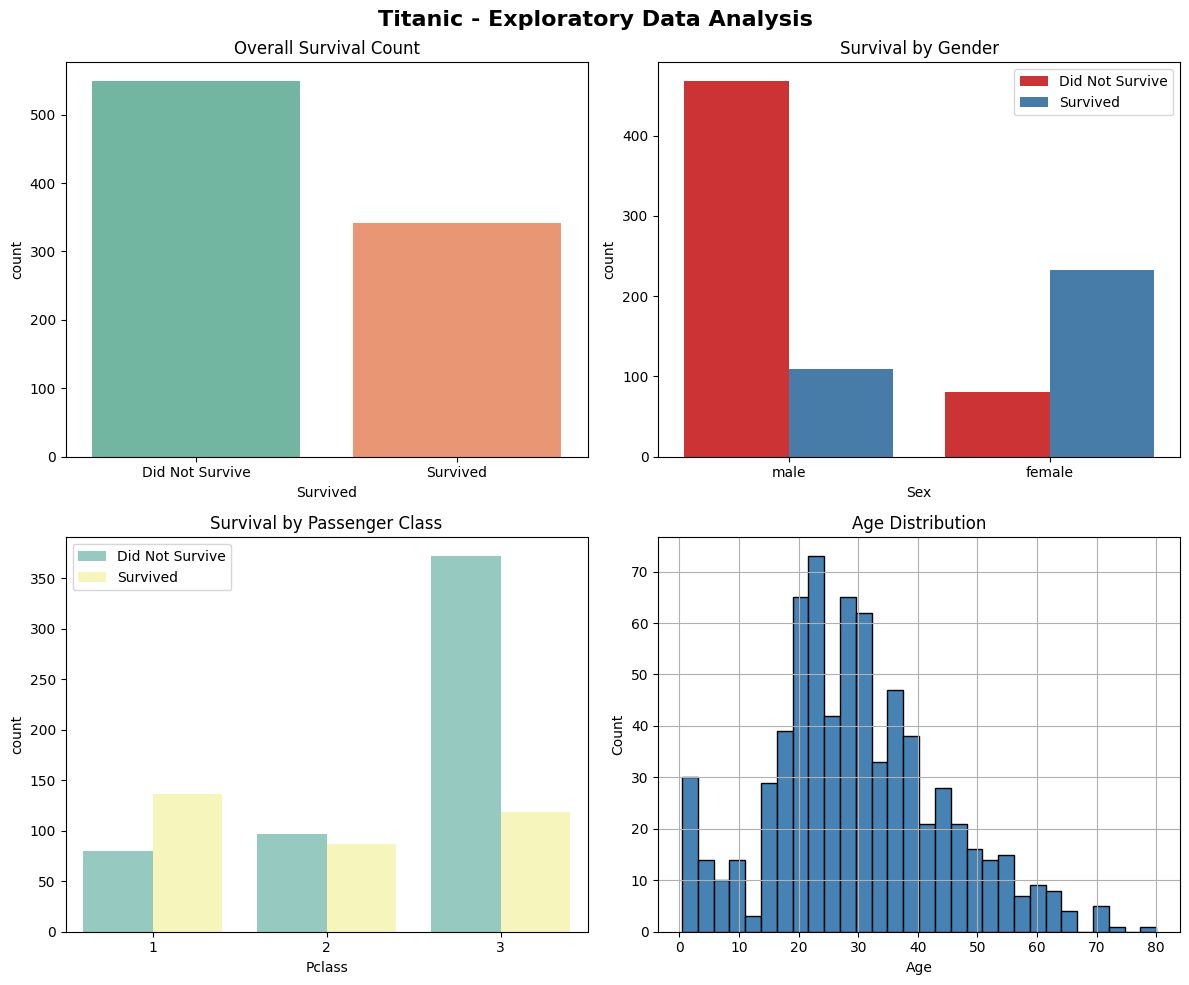

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Titanic - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Overall survival count
sns.countplot(x='Survived', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Overall Survival Count')
axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Survival by Gender')
axes[0, 1].legend(['Did Not Survive', 'Survived'])

# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Survival by Passenger Class')
axes[1, 0].legend(['Did Not Survive', 'Survived'])

# Age Distribution
df['Age'].dropna().hist(ax=axes[1, 1], bins=30, color='steelblue', edgecolor='black')
axes[1, 1].set_title('Age Distribution')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
# Survival rate by gender (as percentages)
print('Survival rate by gender:')
print(df.groupby('Sex')['Survived'].mean() * 100)

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


## Step 5: Handle Missing Values
Check and fill/drop missing data before training.

In [10]:
print(' Missing values per column:')
print(df.isnull().sum())

 Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
# Age → Fill with MEDIAN (less affected by outliers than mean)
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f" Age: filled with median = {df['Age'].median():.1f}")

# Embarked → Fill with MODE (most common value = 'S')
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(f" Embarked: filled with mode = '{df['Embarked'].mode()[0]}'")

# Cabin → Drop entirely (77% missing — too many to fill)
df.drop(columns=['Cabin'], inplace=True)
print(' Cabin: dropped (too many missing values)')

print('\n Missing values after cleaning:')
print(df.isnull().sum())

 Age: filled with median = 28.0
 Embarked: filled with mode = 'S'
 Cabin: dropped (too many missing values)

 Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Step 6: Feature Selection
Drop columns that are not useful for prediction.

In [12]:
# PassengerId → just an ID number
# Name        → too unique (each person has a different name)
# Ticket      → too unique/inconsistent
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print(' Dropped: PassengerId, Name, Ticket')
print('\n Remaining columns:', list(df.columns))
df.head()

 Dropped: PassengerId, Name, Ticket

 Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Step 7: Encode Categorical Variables
ML models only understand **numbers**, not text like `"male"` or `"S"`.

In [13]:
le = LabelEncoder()

# Sex: female → 0, male → 1
df['Sex'] = le.fit_transform(df['Sex'])
print(' Sex encoded     → female=0, male=1')

# Embarked: C → 0, Q → 1, S → 2
df['Embarked'] = le.fit_transform(df['Embarked'])
print(' Embarked encoded → C=0, Q=1, S=2')

print('\n Dataset after encoding:')
df.head()

 Sex encoded     → female=0, male=1
 Embarked encoded → C=0, Q=1, S=2

 Dataset after encoding:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## Step 8: Define Features (X) and Target (y)

In [14]:
# X = input features (everything except Survived)
# y = what we want to predict (Survived)

X = df.drop(columns=['Survived'])
y = df['Survived']

print(f' X (features) shape : {X.shape}')
print(f' y (target)   shape : {y.shape}')
print(f'\n Features used: {list(X.columns)}')

 X (features) shape : (891, 7)
 y (target)   shape : (891,)

 Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## Step 9: Train / Test Split

- **Training set (80%)** → model learns from this  
- **Test set (20%)** → we evaluate how well it learned  
- `random_state=42` ensures the **same split every time** (reproducibility!)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # Fixed seed → same split every run
)

print(f' Training samples : {X_train.shape[0]}')
print(f' Testing  samples : {X_test.shape[0]}')

 Training samples : 712
 Testing  samples : 179


## Step 10: Train the Model
We use **Logistic Regression** — great for binary (Yes/No) prediction problems.

In [16]:
model = LogisticRegression(max_iter=200, random_state=42)
# max_iter=200 → enough iterations for the optimizer to converge

model.fit(X_train, y_train)   # 🚀 Model learns here!

print(' Model trained successfully!')

 Model trained successfully!


## Step 11: Make Predictions

In [17]:
y_pred = model.predict(X_test)

print(f' Predictions (first 10): {y_pred[:10]}')
print(f' Actual values (first 10): {list(y_test[:10])}')

 Predictions (first 10): [0 0 0 1 1 1 1 0 1 1]
 Actual values (first 10): [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]


## Step 12: Evaluate the Model

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f'{'='*45}')
print(f'   Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'{'='*45}')

   Accuracy: 0.8101  (81.01%)


In [19]:
print(' Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

 Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



## Step 13: Confusion Matrix

Shows how many predictions were correct vs incorrect:
- **True Negative (TN):** Correctly predicted NOT survived
- **True Positive (TP):** Correctly predicted SURVIVED  
- **False Positive (FP):** Predicted survived but actually didn't
- **False Negative (FN):** Predicted didn't survive but actually did

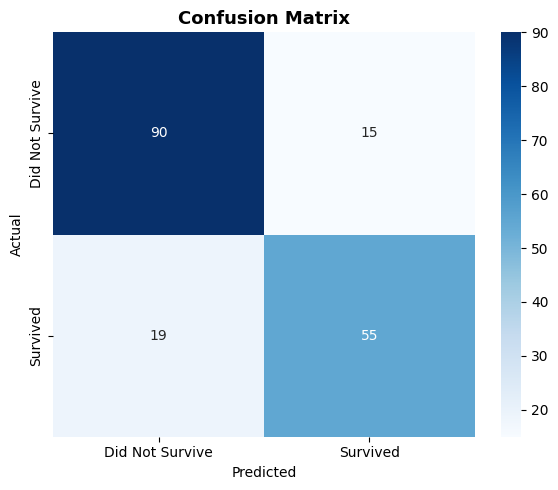

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)
plt.title('Confusion Matrix', fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 14: Feature Importance
Which features matter most? Logistic Regression assigns a **coefficient** to each feature.  
- **Positive** coefficient → increases survival probability  
- **Negative** coefficient → decreases survival probability  
- **Larger absolute value** → more important feature

 Feature Importance:
 Feature  Coefficient
     Sex    -2.596994
  Pclass    -0.930680
   SibSp    -0.293905
Embarked    -0.218777
   Parch    -0.111853
     Age    -0.030433
    Fare     0.002534


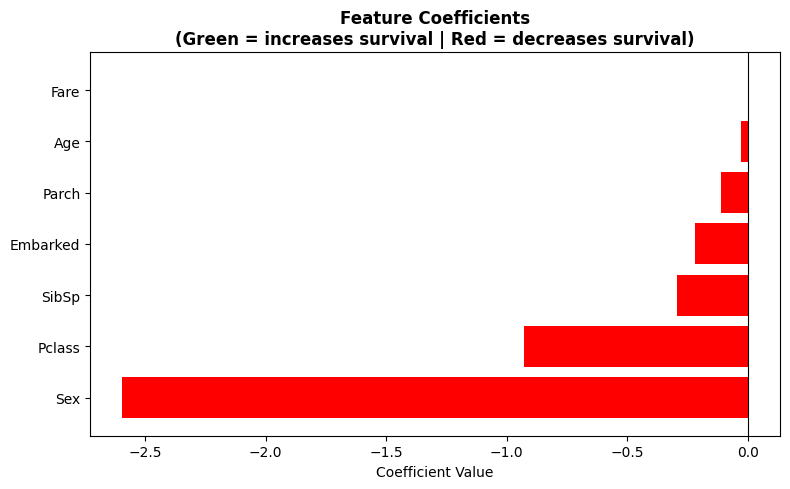

In [21]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(' Feature Importance:')
print(feat_importance.to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in feat_importance['Coefficient']]
plt.barh(feat_importance['Feature'], feat_importance['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients\n(Green = increases survival | Red = decreases survival)',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Step 15: Predict for a New Passenger
Try predicting survival for a custom passenger!

In [22]:
#  Change these values to test different passengers!
# Feature order: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

new_passenger = pd.DataFrame({
    'Pclass':   [3],       # 1=Upper, 2=Middle, 3=Lower class
    'Sex':      [0],       # 0=female, 1=male
    'Age':      [25],      # Age in years
    'SibSp':    [0],       # Siblings/spouses aboard
    'Parch':    [0],       # Parents/children aboard
    'Fare':     [7.5],     # Ticket fare
    'Embarked': [2]        # 0=Cherbourg, 1=Queenstown, 2=Southampton
})

prediction  = model.predict(new_passenger)[0]
probability = model.predict_proba(new_passenger)[0]

print(' Passenger Details: 3rd class female, age 25, Southampton')
print(f'\n Survival Probability : {probability[1]*100:.1f}%')
print(f' Prediction           : {" SURVIVED" if prediction == 1 else "❌ DID NOT SURVIVE"}')

 Passenger Details: 3rd class female, age 25, Southampton

 Survival Probability : 64.2%
 Prediction           :  SURVIVED


---
##  Project Summary

| Item | Details |
|------|---------|
| **Dataset** | Titanic train.csv (891 passengers) |
| **Algorithm** | Logistic Regression |
| **Train/Test Split** | 80% / 20% |
| **Key Feature** | Sex (women had much higher survival rate) |

###  Key Learnings
- **Missing values** must be handled before training (fill or drop)
- **Label Encoding** converts text categories → numbers
- **`random_state`** in train_test_split ensures reproducibility
- **Logistic Regression** works well for Yes/No prediction problems
- **Feature coefficients** tell us which features matter most
